In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import pandas as pd
from attention_classifier import AttentionClassifier

df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
import pandas as pd


features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3


import pandas as pd
from pathlib import Path

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [4]:
def get_events_tst(smeared_hash: str):
    smeared_fvt_tinfo = TrainingInfo.load(smeared_hash)
        
    base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
    base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
    ms_hash = base_fvt_tinfo.ms_hash
    ms_idx = base_fvt_tinfo.ms_idx
    msamples = MotherSamples.load(ms_hash)
    tst_scdinfo = msamples.scdinfo[~ms_idx]
    df_tst = tst_scdinfo.fetch_data(loaded_df)
    events_tst = EventsData.from_dataframe(df_tst, features)
    return events_tst

def calculate_SR_stats(events_tst, hash):
    smeared_fvt_tinfo = TrainingInfo.load(hash)
    base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
    base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
    base_fvt_model = base_fvt_tinfo.load_trained_model("best")
    base_fvt_model.eval()
    base_fvt_model: FvTClassifier
    base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
    base_fvt_scores = base_fvt_scores.numpy()[:, 1]
    base_q_repr = base_q_repr.numpy()
    base_gamma = base_fvt_scores / (1 - base_fvt_scores)
    smeared_fvt_model = smeared_fvt_tinfo.load_trained_model("best")
    smeared_fvt_model.eval()
    smeared_fvt_model.to(torch.device("cuda"))
    smeared_fvt_model: AttentionClassifier
    fvt_smeared = smeared_fvt_model.predict(base_q_repr).numpy()[:, 1]
    gamma_smeared = fvt_smeared / (1 - fvt_smeared)
    SR_stats_tst = np.log(base_gamma / gamma_smeared)
    return SR_stats_tst

def plot_mean_and_fill_between_std(x, y_list, ax, **kwargs):
    y_mean = np.mean(y_list, axis=0)
    y_std = np.std(y_list, axis=0)
    ax.plot(x, y_mean, **kwargs)
    if "color" in kwargs:
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2, color=kwargs["color"])
    else:
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.2)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [06:49<00:00,  8.18s/it]


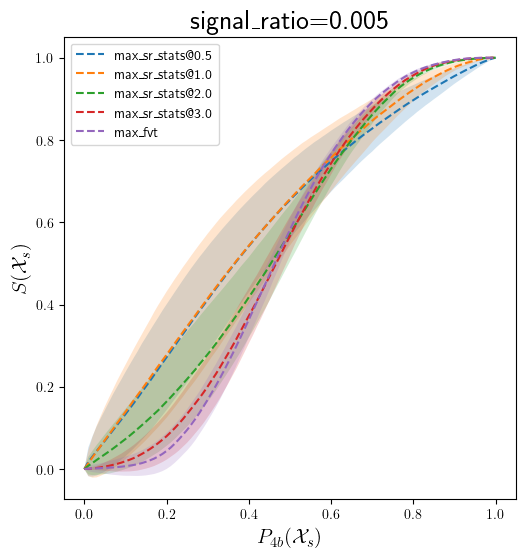

100%|██████████| 50/50 [06:45<00:00,  8.10s/it]


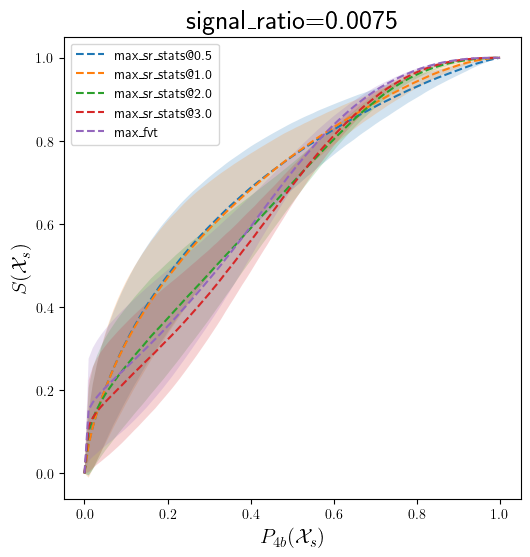

100%|██████████| 50/50 [05:47<00:00,  6.96s/it]


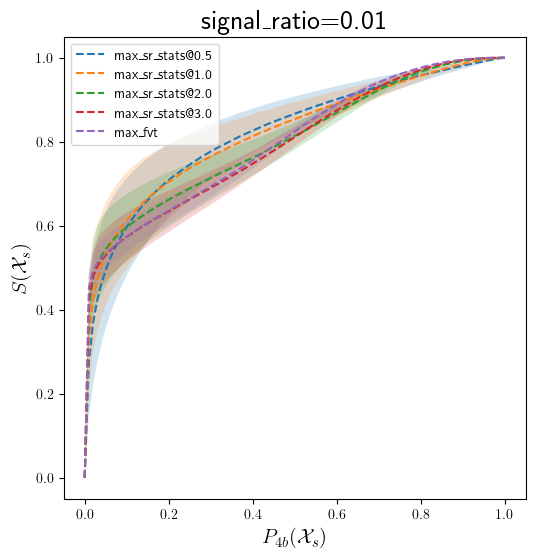

 46%|████▌     | 23/50 [03:42<04:20,  9.66s/it]


KeyError: 'SR_stats_tst'

In [5]:
from plots import get_weights_by_sr_stats
import tqdm

n_3b = 100_0000
seeds = range(50)
signal_ratios = [0.005, 0.0075, 0.01, 0.02]
ensemble_seeds = range(15)
noise_scales = [0.5, 1.0, 2.0, 3.0]

for signal_ratio in signal_ratios:    
    w_4b_ratio_points = np.arange(0, 1.01, 0.01)
    signal_in_sr_list_dict = {"max_fvt": []}
    for noise_scale in noise_scales:
        signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"] = []
    
    for seed in tqdm.tqdm(seeds):
        base_fvt_scores_list = []
        for noise_scale in noise_scales:
            hashes, hparams = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                                "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                    and x["seed"] == seed 
                                                                    and x["n_3b"] == n_3b), 
                                                "smearing": lambda x: x["noise_scale"] == noise_scale
                                                }, return_hparams=True, use_cached_metadata=True)
            if len(hashes) != 15:
                print(f"Expected 15 hashes, got {len(hashes)} for signal_ratio={signal_ratio}, seed={seed}, noise_scale={noise_scale}")
            
            events_tst = get_events_tst(hashes[0])
            SR_stats_list = []
            
            for hash in hashes:
                smeared_fvt_tinfo = TrainingInfo.load(hash)
                SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
                SR_stats_list.append(SR_stats_tst)
                if noise_scale == 1.0:
                    if "base_fvt_score_tst" in smeared_fvt_tinfo.aux_info.keys():
                        base_fvt_scores = smeared_fvt_tinfo.aux_info["base_fvt_score_tst"]  
                    else:
                        raise ValueError("base_fvt_score_tst not found")
                    base_fvt_scores_list.append(base_fvt_scores)
                
            max_sr_stats = np.max(SR_stats_list, axis=0)
            w_4b_ratio_SR_max, w_signal_ratio_SR_max = get_weights_by_sr_stats(events_tst, max_sr_stats)
            w_signal_ratio_SR_max = np.interp(w_4b_ratio_points, w_4b_ratio_SR_max, w_signal_ratio_SR_max)
            signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"].append(w_signal_ratio_SR_max)
            
        if len(base_fvt_scores_list) != 15:
            print(f"Expected 15 base_fvt_scores_list, got {len(base_fvt_scores_list)} for signal_ratio={signal_ratio}, seed={seed}")
        base_fvt_scores_max = np.max(base_fvt_scores_list, axis=0)
        w_4b_ratio_base_max, w_signal_ratio_base_max = get_weights_by_sr_stats(events_tst, base_fvt_scores_max)
        w_signal_ratio_base_max = np.interp(w_4b_ratio_points, w_4b_ratio_base_max, w_signal_ratio_base_max)
        signal_in_sr_list_dict["max_fvt"].append(w_signal_ratio_base_max)
        
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    for noise_scale in noise_scales:
        plot_mean_and_fill_between_std(w_4b_ratio_points, signal_in_sr_list_dict[f"max_sr_stats@{noise_scale}"], 
                                       ax, label=f"max_sr_stats@{noise_scale}", linestyle="--")
    plot_mean_and_fill_between_std(w_4b_ratio_points, signal_in_sr_list_dict["max_fvt"], ax, label="max_fvt", linestyle="--")
    
    ax.set_title(f"signal_ratio={signal_ratio}")
    ax.legend()
    ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
    ax.set_ylabel(r"$S(\mathcal{X}_s)$")
    ax.set_aspect("equal")
    
    plt.savefig(f"data/plots/smeared_gamma_ensemble_avg_signal_ratio={signal_ratio}_full.pdf", dpi=200)
    plt.show()
    plt.close()

In [ ]:
signal_ratio = 0.02
n_3b = 100_0000
for noise_scale in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    print(noise_scale)
    hashes = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                "dataset": lambda x: (x["signal_ratio"] == signal_ratio and x["n_3b"] == n_3b), 
                                "smearing": lambda x: x["noise_scale"] == noise_scale
                                })
    print(len(hashes))

0.5


NameError: name 'TrainingInfo' is not defined

In [8]:
# Saving SR_stats: see save_sr_stats.py

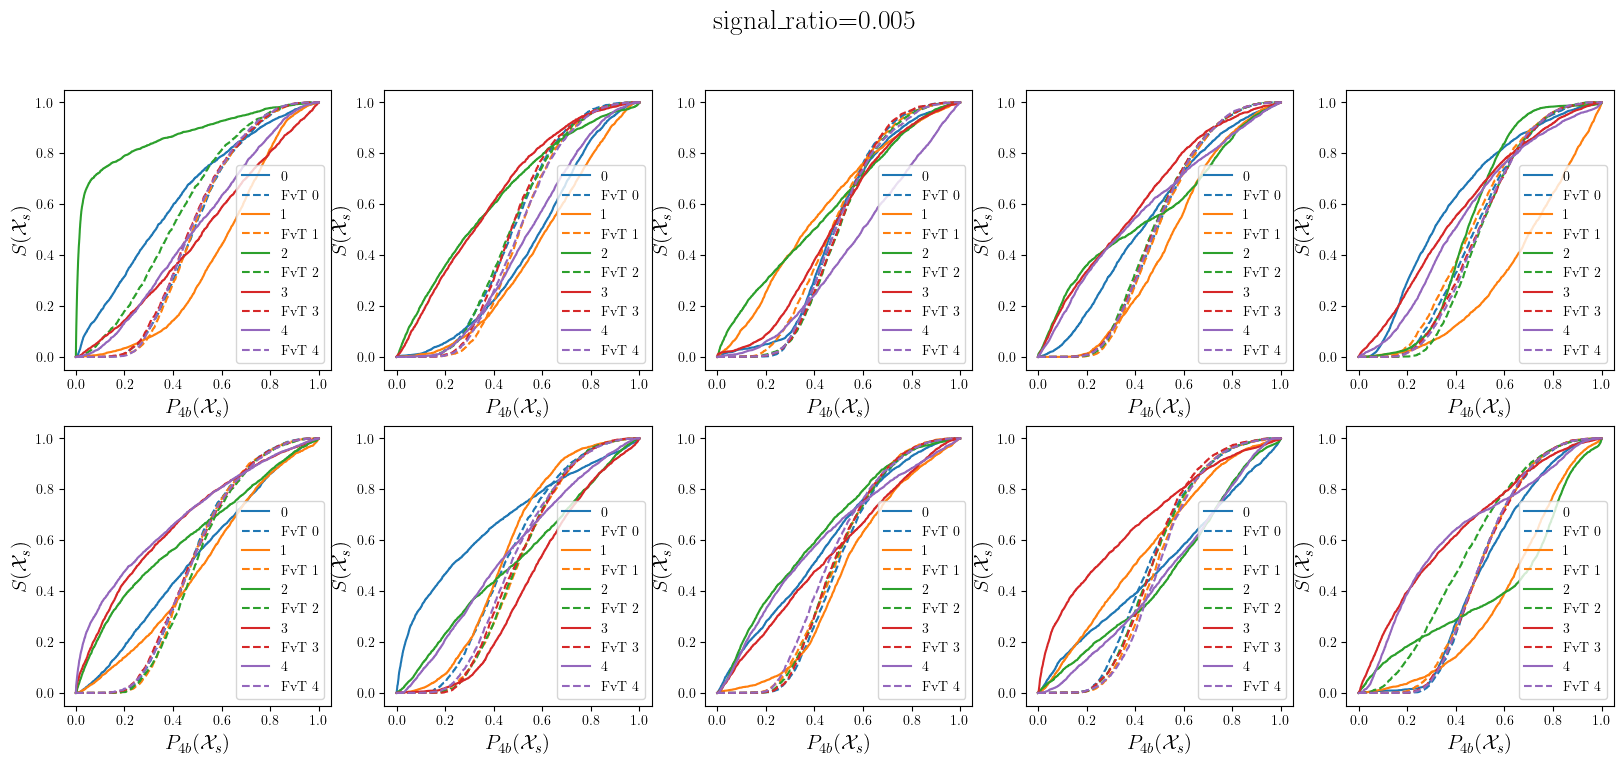

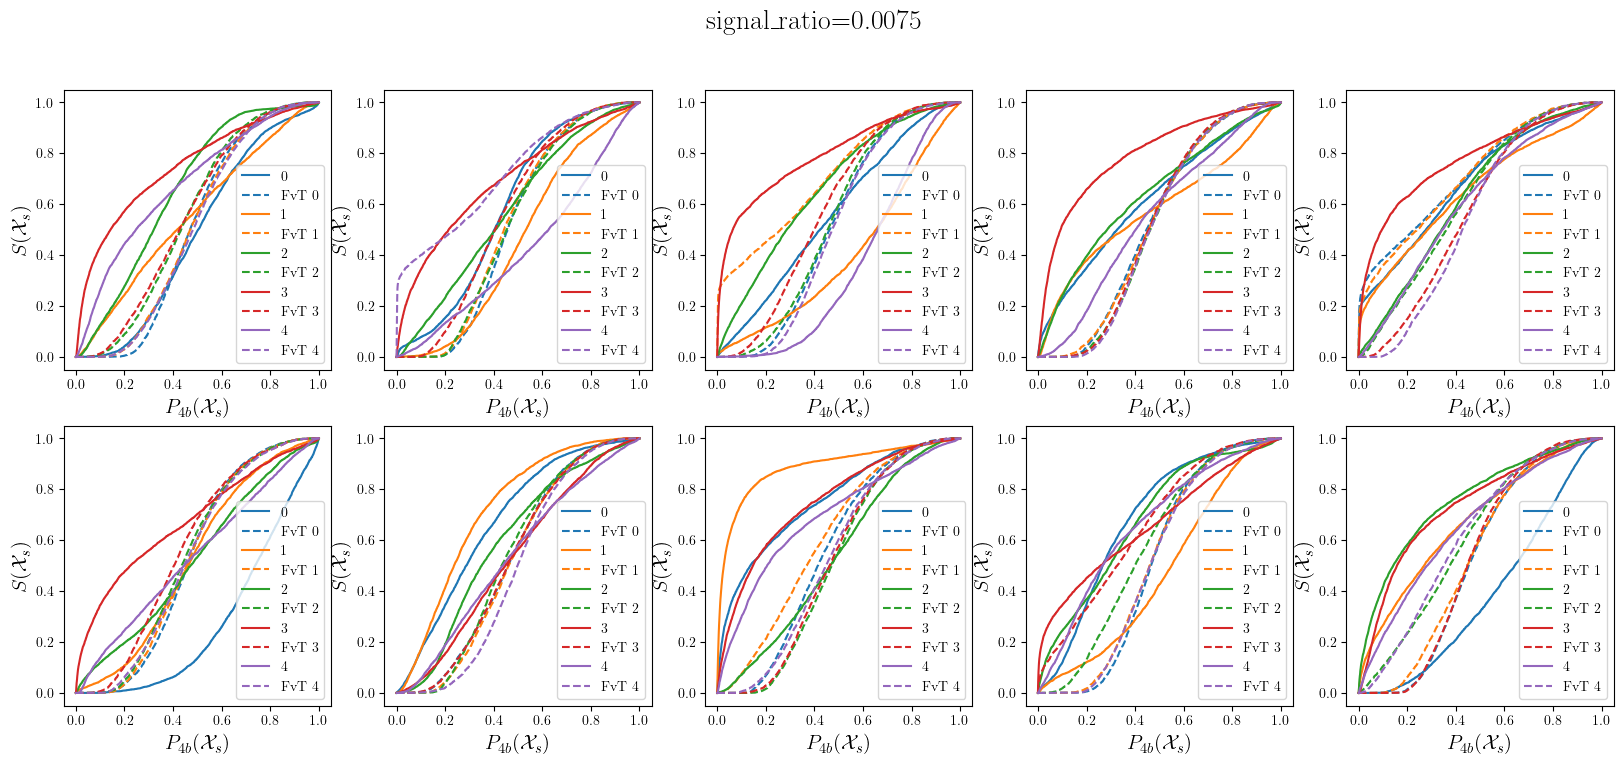

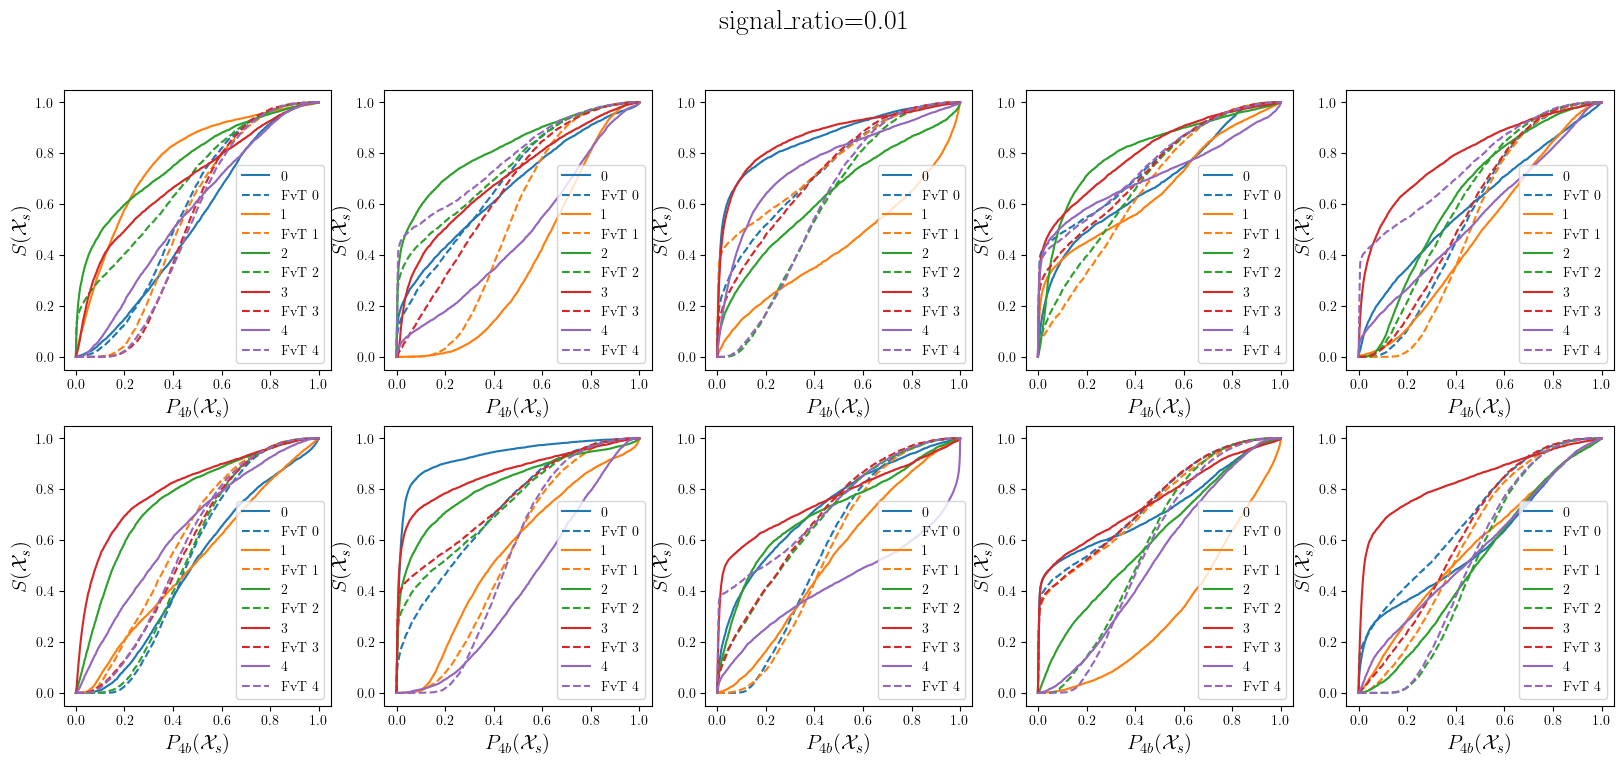

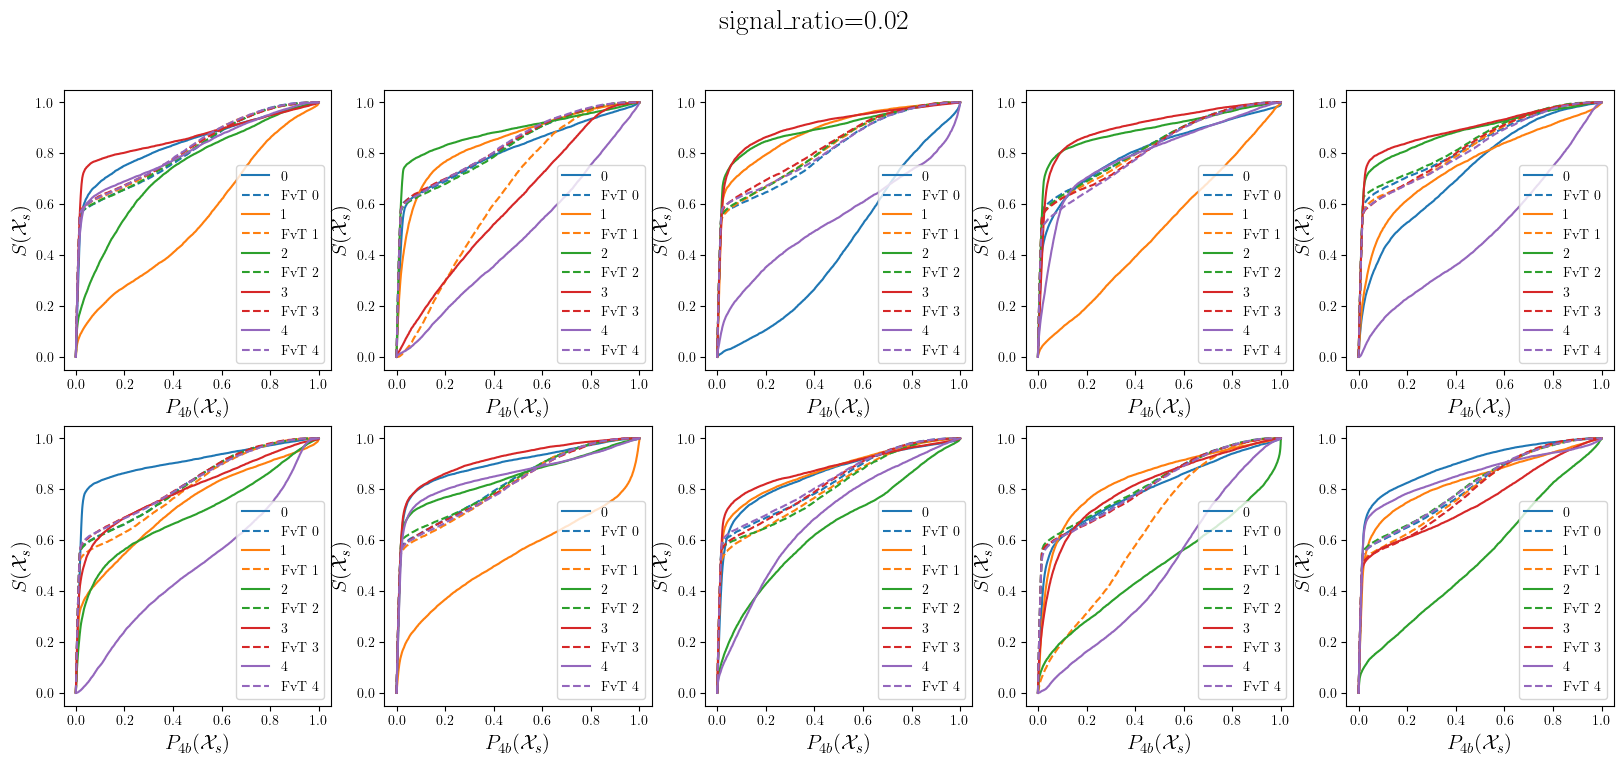

In [25]:
from itertools import product
from plots import plot_sr_stats

n_3b = 100_0000
seeds = range(10)
signal_ratios = [0.005, 0.0075, 0.01, 0.02]
ensemble_seeds = range(5)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for signal_ratio in signal_ratios:
    nrows = 2
    ncols = (len(seeds) + nrows - 1) // nrows
    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    fig.suptitle(f"signal_ratio={signal_ratio}")
    axs = axs.flatten()
    
    for ax, seed in zip(axs, seeds):
        hashes, hparams = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                            "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                and x["seed"] == seed 
                                                                and x["n_3b"] == n_3b), 
                                            }, return_hparams=True)
        # sort hashes by train_seed
        hashes = sorted(hashes, key=lambda x: hparams[hashes.index(x)]["train_seed"])

        events_tst = get_events_tst(hashes[0])
        for color, hash in zip(colors, hashes):
            smeared_fvt_tinfo = TrainingInfo.load(hash)
            train_seed = smeared_fvt_tinfo.hparams["train_seed"]
            
            base_fvt_tinfo = TrainingInfo.load(smeared_fvt_tinfo.hparams["encoder_hash"])
            base_fvt_model = base_fvt_tinfo.load_trained_model("best")
            base_fvt_model.eval()
            base_fvt_model: FvTClassifier
            base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
            base_fvt_scores = base_fvt_scores.numpy()[:, 1]
            
            if "SR_stats_tst" in smeared_fvt_tinfo.aux_info.keys():
                SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
            else:
                SR_stats_tst = calculate_SR_stats(events_tst, hash)
                smeared_fvt_tinfo.update_aux_info(SR_stats_tst=SR_stats_tst)
                smeared_fvt_tinfo.save()
                
            plot_sr_stats(events_tst, SR_stats_tst, ax, label=f"{train_seed}", color=color)
            plot_sr_stats(events_tst, base_fvt_scores, ax, label=f"FvT {train_seed}", color=color, linestyle="--")
        # ax.set_title("Signal Concentration")
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        ax.legend(loc="lower right")
    plt.savefig(f"data/plots/smeared_gamma_ensemble_with_base_fvt_signal_ratio={signal_ratio}.pdf")
    plt.show()
    plt.close()

In [5]:
from itertools import product
from plots import plot_sr_stats

n_3b = 100_0000
seeds = range(10)
signal_ratios = [0.005, 0.0075, 0.01, 0.02]
ensemble_seeds = range(15)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for signal_ratio in signal_ratios:
    nrows = 2
    ncols = (len(seeds) + nrows - 1) // nrows
    for seed in seeds:
        hashes, hparams = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                            "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                and x["seed"] == seed 
                                                                and x["n_3b"] == n_3b), 
                                            }, return_hparams=True)
        # print([hp["dataset"]["seed"] for hp in hparams])
        smeared_fvt_tinfo = TrainingInfo.load(hashes[0])
        ms_hash = smeared_fvt_tinfo.ms_hash
        ms_idx = smeared_fvt_tinfo.ms_idx
        for hash in hashes:
            smeared_fvt_tinfo = TrainingInfo.load(hash)
            assert smeared_fvt_tinfo.ms_hash == ms_hash
            assert np.all(smeared_fvt_tinfo.ms_idx == ms_idx)
print("All good")

All good


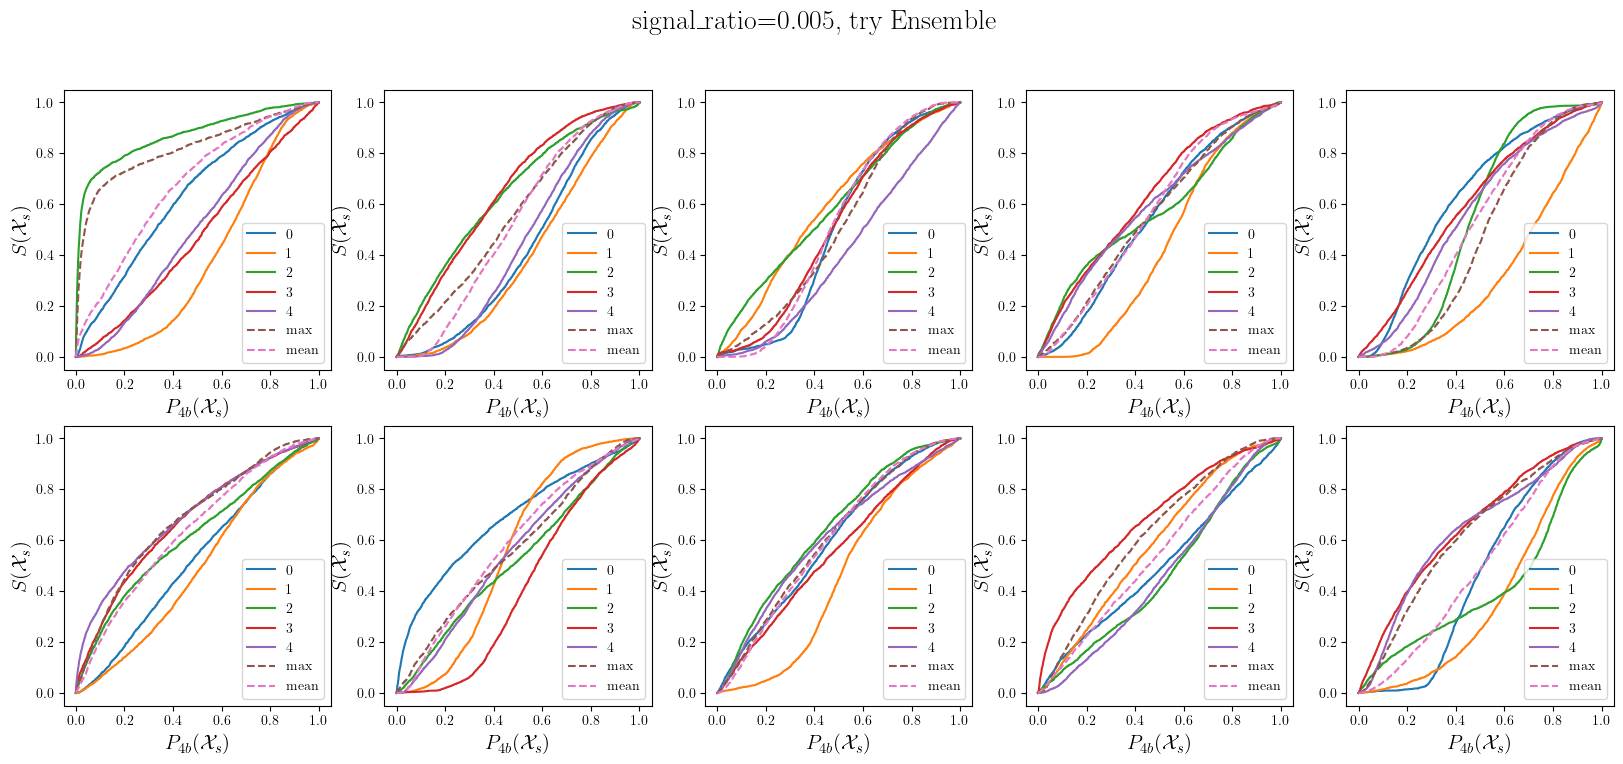

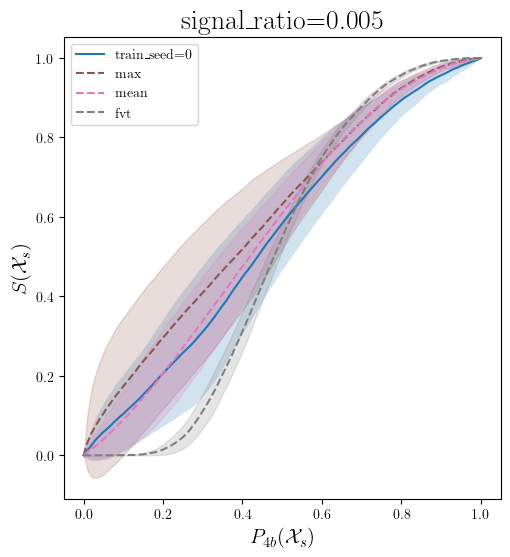

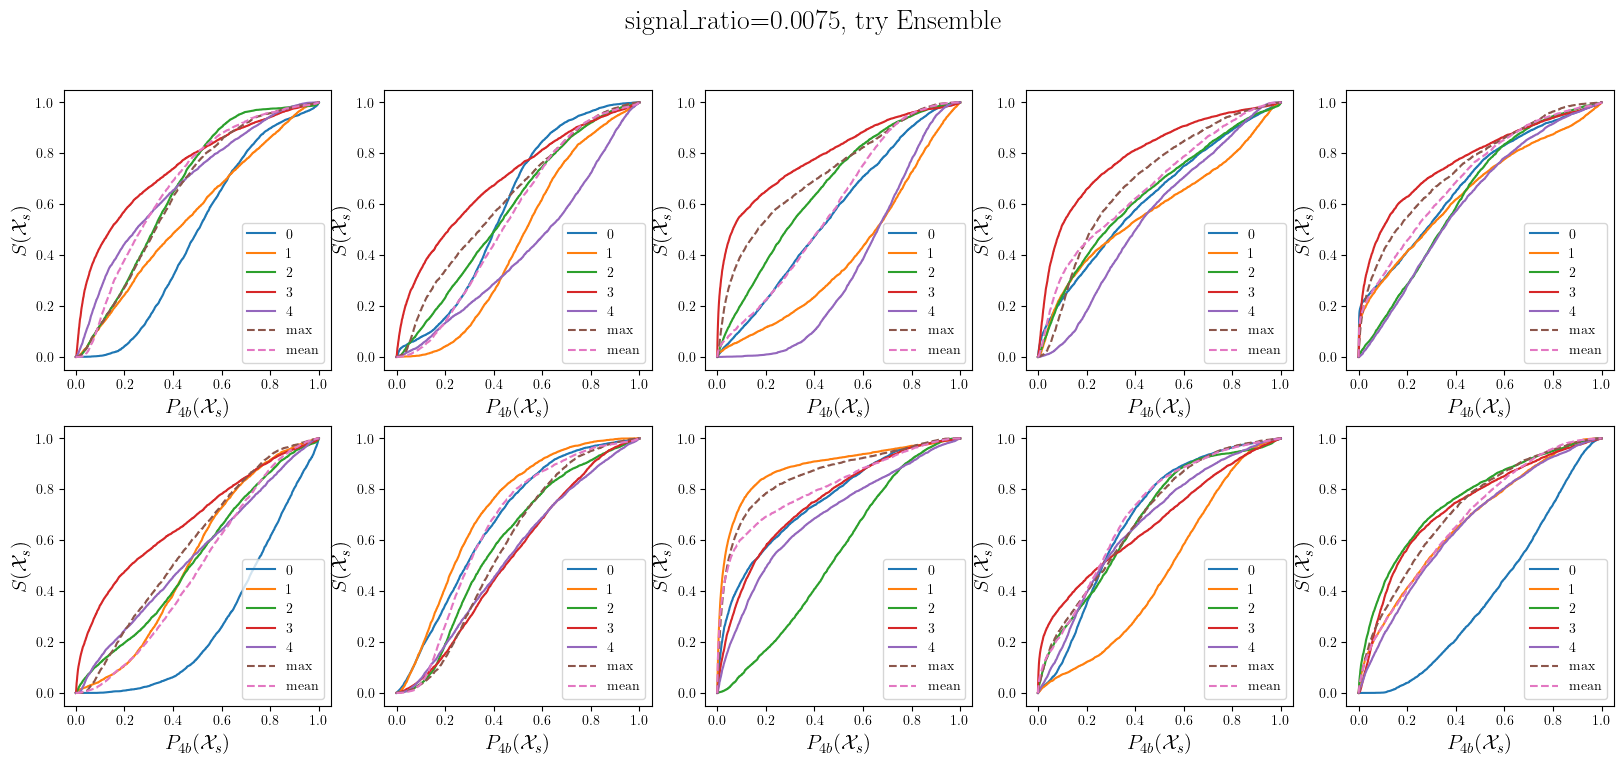

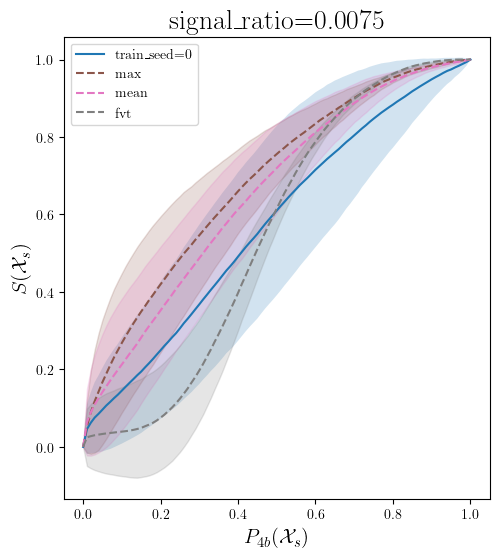

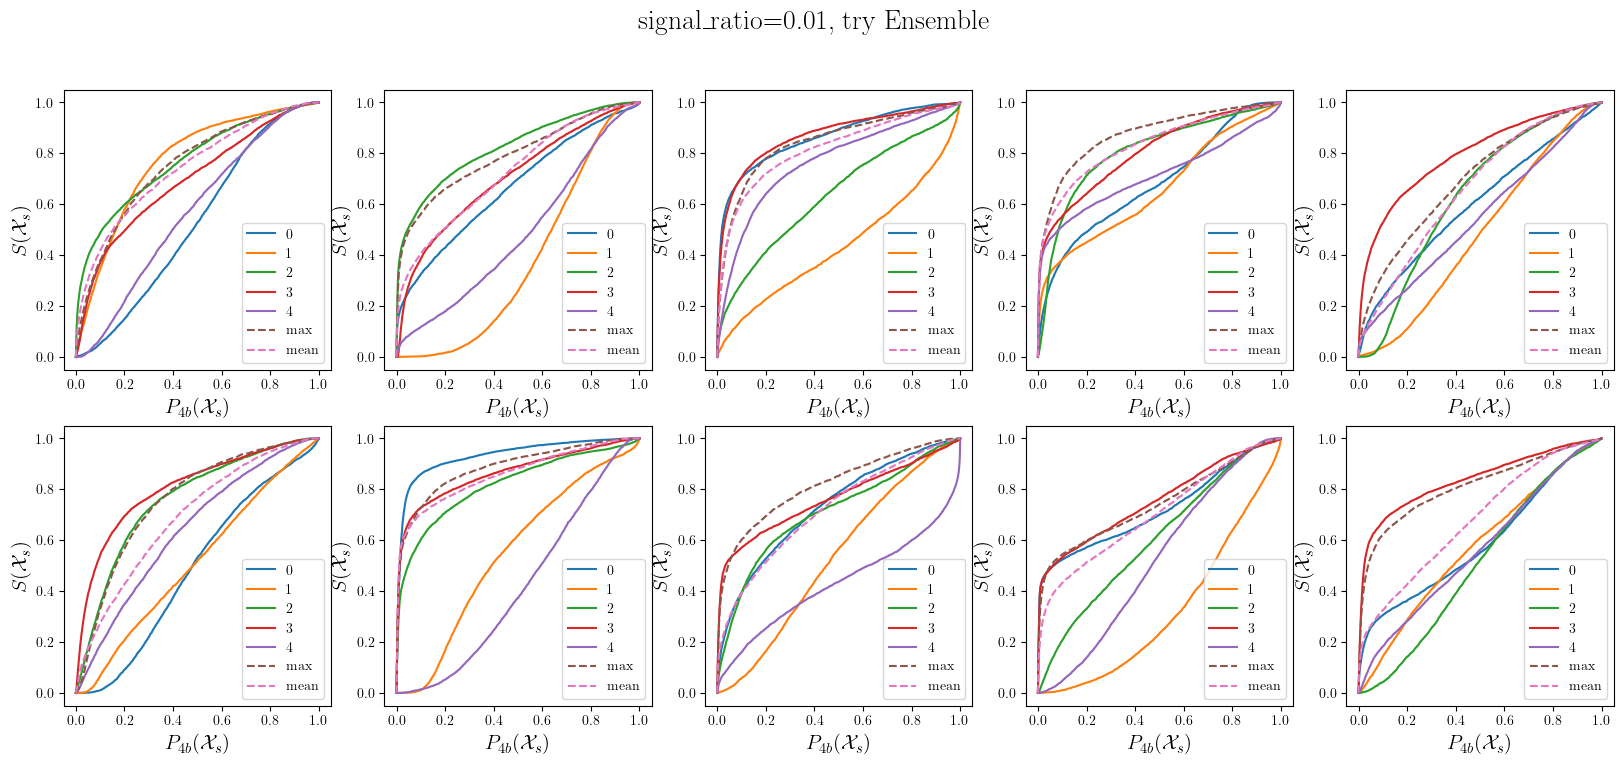

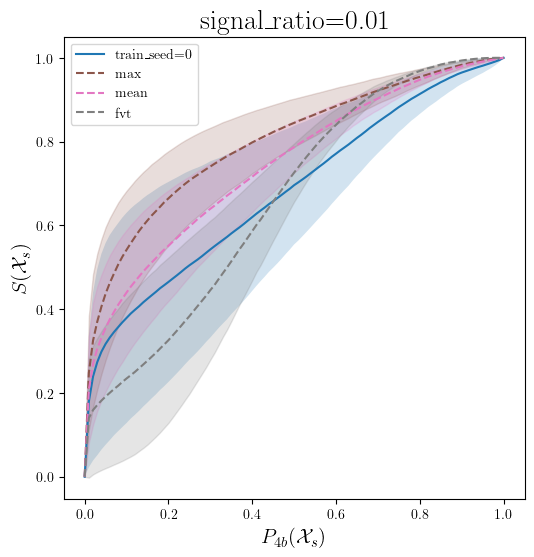

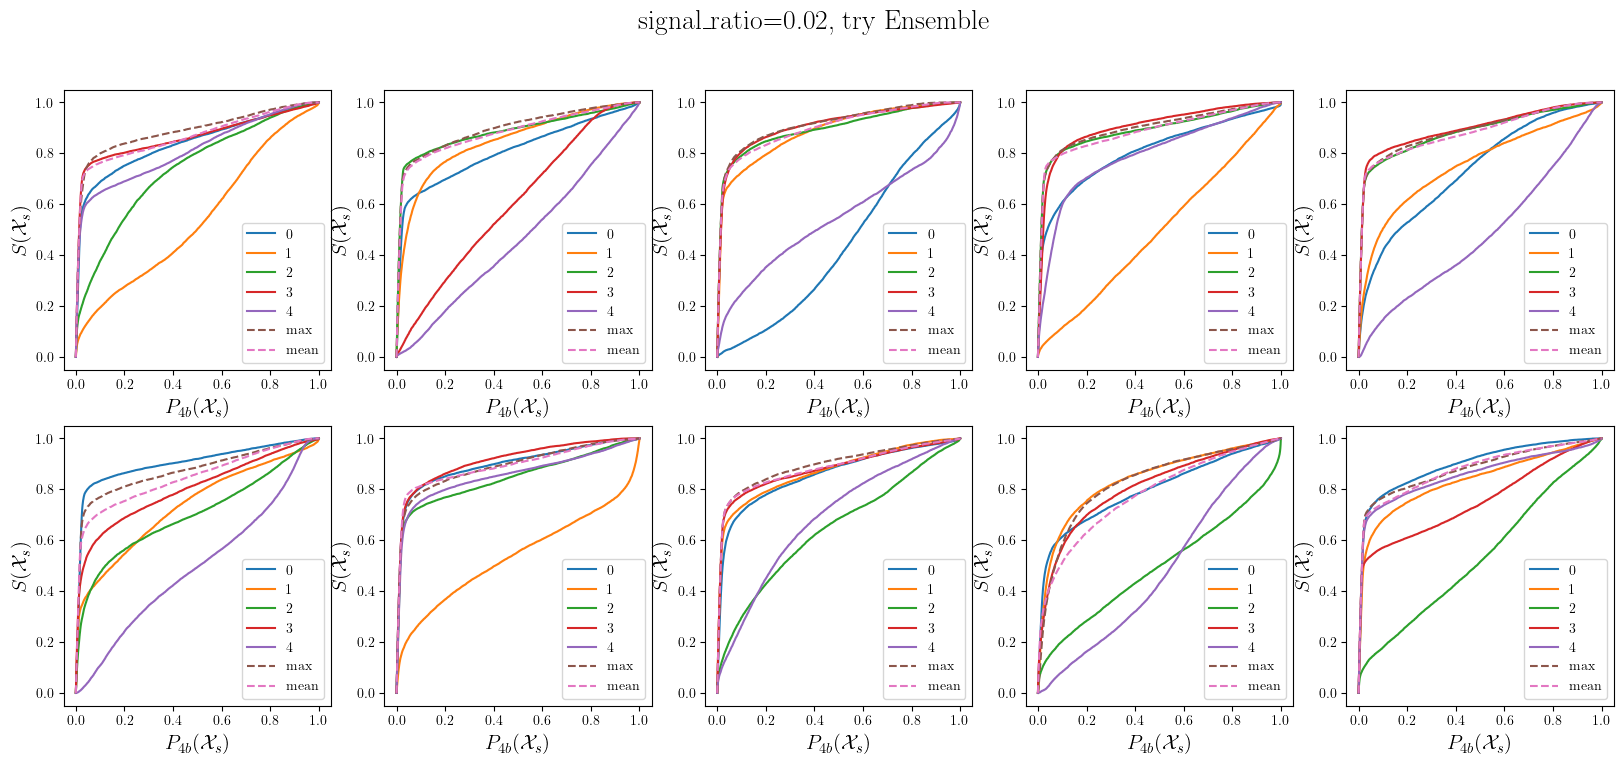

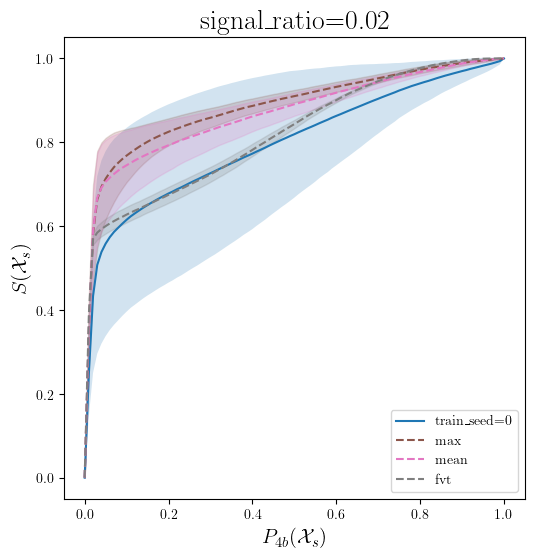

In [8]:
from itertools import product
from plots import plot_sr_stats, get_weights_by_sr_stats

n_3b = 100_0000
seeds = range(10)
signal_ratios = [0.005, 0.0075, 0.01, 0.02]
ensemble_seeds = range(5)
colors = plt.get_cmap("tab10").colors

for signal_ratio in signal_ratios:
    nrows = 2
    ncols = (len(seeds) + nrows - 1) // nrows
    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    fig.suptitle(f"signal_ratio={signal_ratio}, try Ensemble")
    axs = axs.flatten()
    
    w_4b_ratio_points = np.arange(0, 1.01, 0.01)
    w_signal_ratio_list = {"max": [], "mean": [], "fvt": []}
    for train_seed in seeds:
        w_signal_ratio_list[train_seed] = []
    
    for ax, seed in zip(axs, seeds):
        ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
        ax.set_ylabel(r"$S(\mathcal{X}_s)$")
        
        hashes, hparams = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                            "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                and x["seed"] == seed 
                                                                and x["n_3b"] == n_3b), 
                                            }, return_hparams=True)
        # sort hashes by train_seed
        hashes = sorted(hashes, key=lambda x: hparams[hashes.index(x)]["train_seed"])
        events_tst = get_events_tst(hashes[0])
        SR_stats_list = []
        for color, hash in zip(colors, hashes):
            smeared_fvt_tinfo = TrainingInfo.load(hash)
            train_seed = smeared_fvt_tinfo.hparams["train_seed"]
            if "SR_stats_tst" in smeared_fvt_tinfo.aux_info.keys():
                SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
            else:
                base_fvt_tinfo = TrainingInfo.load(smeared_fvt_tinfo.hparams["encoder_hash"])
                base_fvt_score = base_fvt_tinfo.aux_info["base_fvt_score"]
                smeared_fvt_score = smeared_fvt_tinfo.aux_info["smeared_fvt_score"]
                SR_stats_tst = np.log(base_fvt_score / (1 - base_fvt_score)) - np.log(smeared_fvt_score / (1 - smeared_fvt_score))
            SR_stats_list.append(SR_stats_tst)
            w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_tst)
            plot_sr_stats(events_tst, SR_stats_tst, ax, label=f"{train_seed}", color=color)
            w_signal_ratio = np.interp(w_4b_ratio_points, w_4b_ratio, w_signal_ratio)
            w_signal_ratio_list[train_seed].append(w_signal_ratio)
            
            if train_seed == 0:
                base_fvt_tinfo = TrainingInfo.load(smeared_fvt_tinfo.hparams["encoder_hash"])
                base_fvt_model = base_fvt_tinfo.load_trained_model("best")
                base_fvt_model.eval()
                base_fvt_model: FvTClassifier
                base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
                base_fvt_scores = base_fvt_scores.numpy()[:, 1]
                
        w_4b_ratio_fvt, w_signal_ratio_fvt = get_weights_by_sr_stats(events_tst, base_fvt_scores)
        w_signal_ratio_fvt = np.interp(w_4b_ratio_points, w_4b_ratio_fvt, w_signal_ratio_fvt)
        w_signal_ratio_list["fvt"].append(w_signal_ratio_fvt)

        SR_stats_max = np.max(SR_stats_list, axis=0)
        w_4b_ratio_max, w_signal_ratio_max = get_weights_by_sr_stats(events_tst, SR_stats_max)
        w_signal_ratio_max = np.interp(w_4b_ratio_points, w_4b_ratio_max, w_signal_ratio_max)
        w_signal_ratio_list["max"].append(w_signal_ratio_max)
        
        SR_stats_mean = np.mean(SR_stats_list, axis=0)
        w_4b_ratio_mean, w_signal_ratio_mean = get_weights_by_sr_stats(events_tst, SR_stats_mean)
        w_signal_ratio_mean = np.interp(w_4b_ratio_points, w_4b_ratio_mean, w_signal_ratio_mean)
        w_signal_ratio_list["mean"].append(w_signal_ratio_mean)
        
        
        
        plot_sr_stats(events_tst, SR_stats_max, ax, label="max", linestyle="--", color=colors[len(ensemble_seeds)])
        plot_sr_stats(events_tst, SR_stats_mean, ax, label="mean", linestyle="--", color=colors[len(ensemble_seeds) + 1])
        ax.legend(loc="lower right")
    plt.savefig(f"data/plots/smeared_gamma_ensemble_by_seeds_signal_ratio={signal_ratio}.pdf")
    plt.show()
    plt.close()
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list[0], ax, label="train_seed=0")
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list["max"], ax, label="max", linestyle="--", color=colors[len(ensemble_seeds)])
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list["mean"], ax, label="mean", linestyle="--", color=colors[len(ensemble_seeds) + 1])
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list["fvt"], ax, label="fvt", linestyle="--", color=colors[len(ensemble_seeds) + 2])
    
    ax.set_title(f"signal_ratio={signal_ratio}")
    ax.legend()
    ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
    ax.set_ylabel(r"$S(\mathcal{X}_s)$")
    ax.set_aspect("equal")
    
    plt.savefig(f"data/plots/smeared_gamma_ensemble_avg_signal_ratio={signal_ratio}.pdf")
    plt.show()
    plt.close()

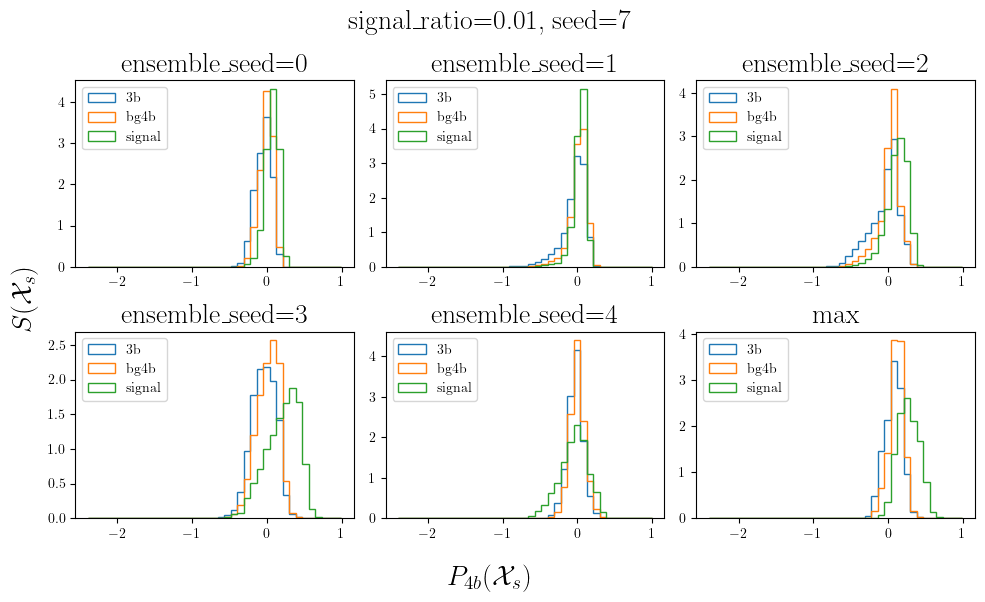

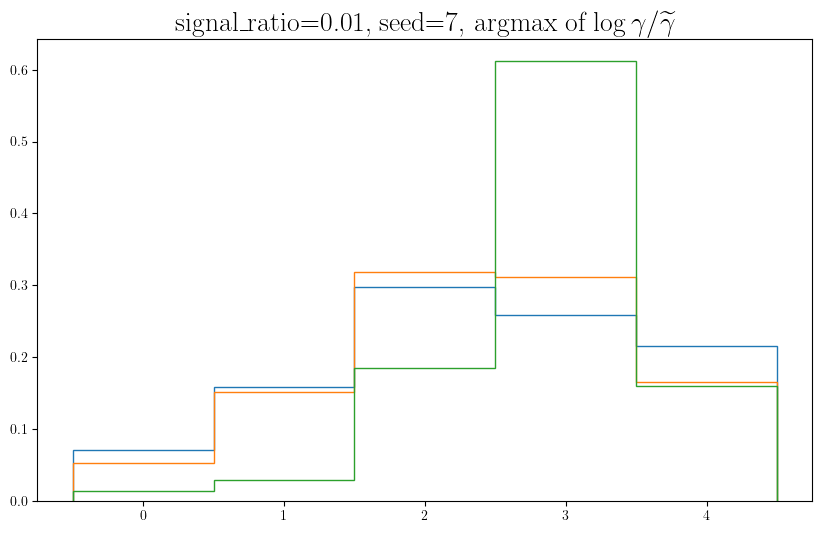

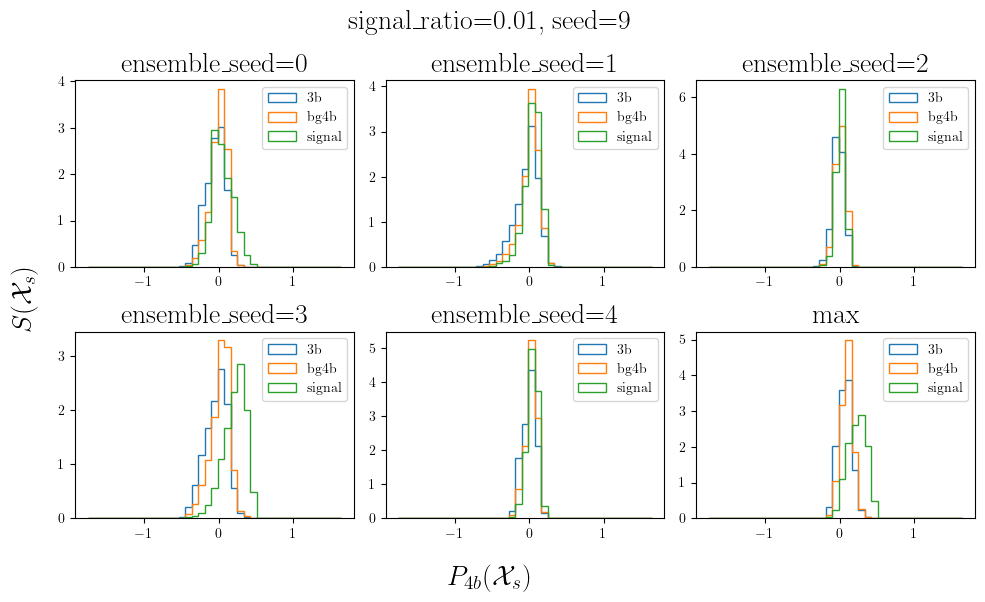

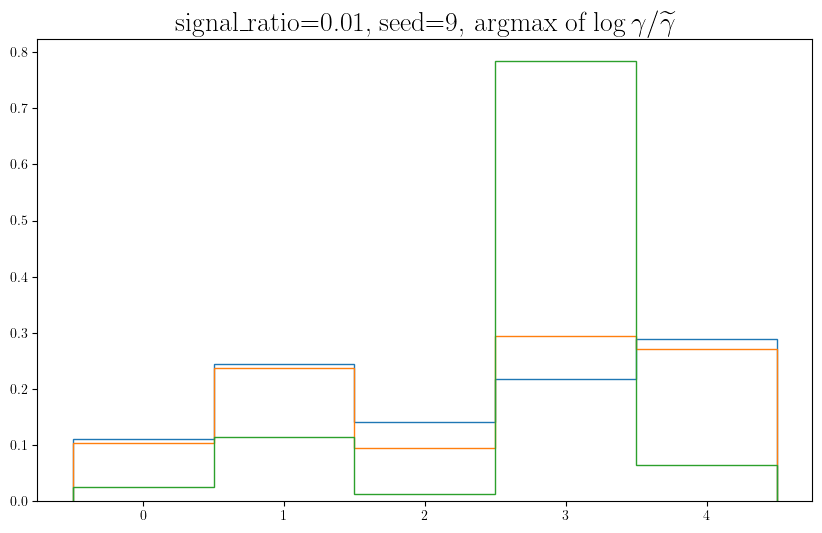

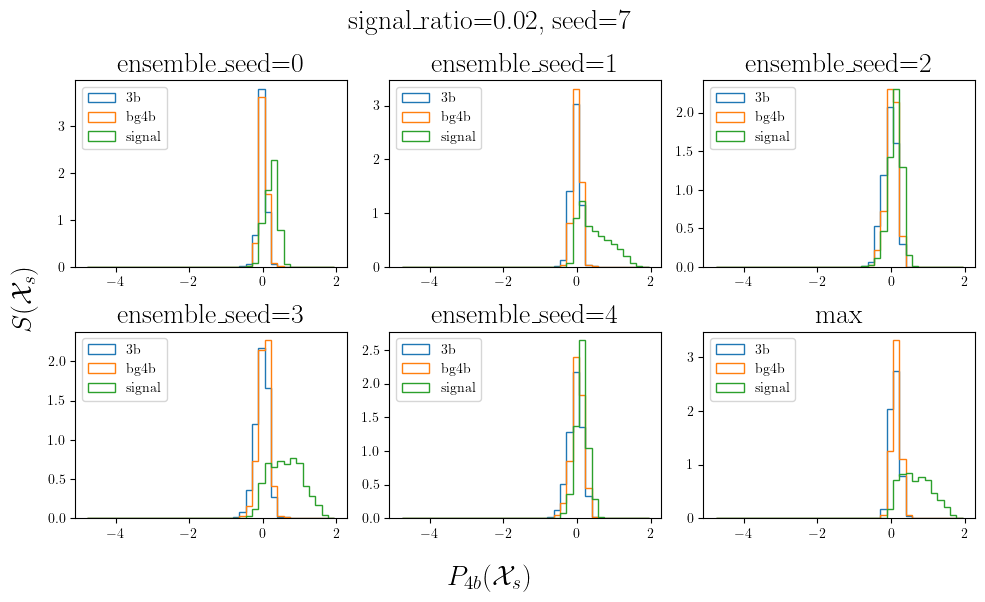

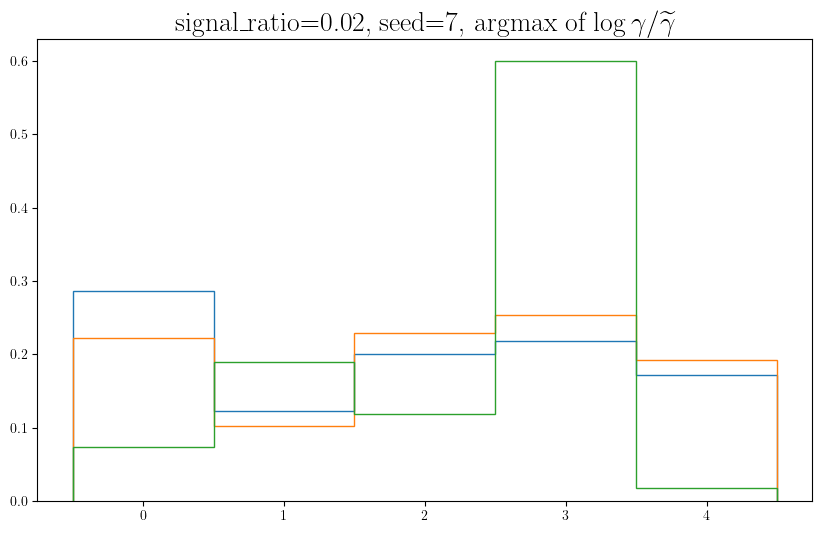

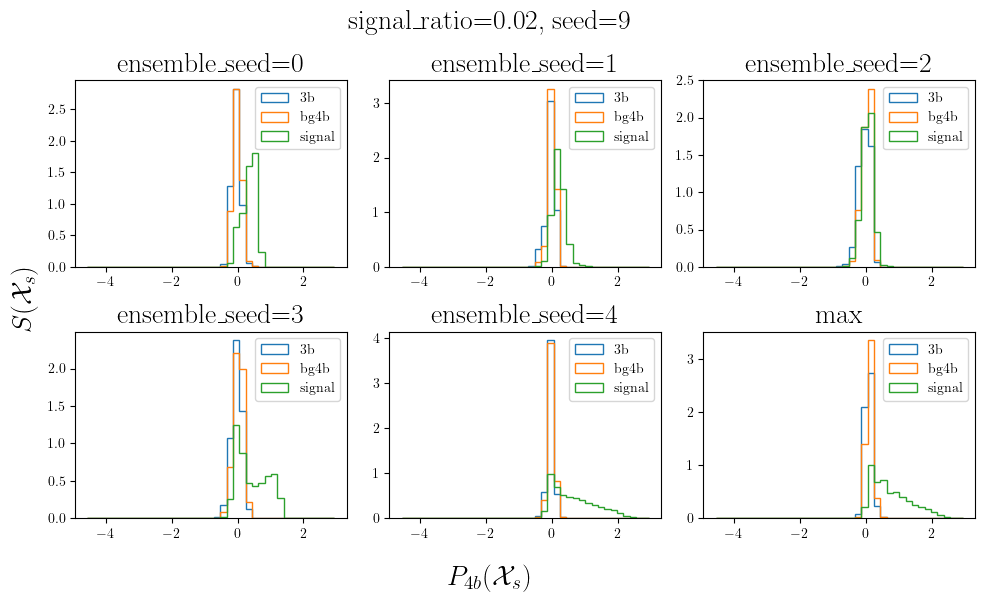

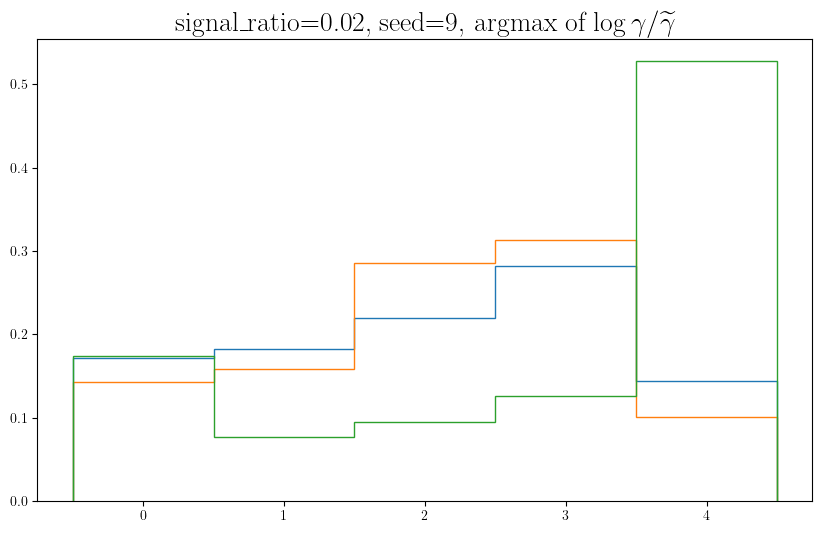

In [50]:
# Why ensemble works?

from itertools import product
from plots import plot_sr_stats, get_weights_by_sr_stats

n_3b = 100_0000
seeds = [7, 9]
signal_ratios = [0.01, 0.02]
ensemble_seeds = range(5)
colors = plt.get_cmap("tab10").colors

for signal_ratio in signal_ratios:
    nrows = 2
    ncols = (len(seeds) + nrows - 1) // nrows
    
    w_4b_ratio_points = np.arange(0, 1.01, 0.01)
    w_signal_ratio_list = {"max": [], "mean": []}
    for ensemble_seed in ensemble_seeds:
        w_signal_ratio_list[ensemble_seed] = []
    
    for seed in seeds:        
        hashes, hparams = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                            "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                and x["seed"] == seed 
                                                                and x["n_3b"] == n_3b), 
                                            }, return_hparams=True)
        # sort hashes by train_seed
        hashes = sorted(hashes, key=lambda x: hparams[hashes.index(x)]["train_seed"])
        events_tst = get_events_tst(hashes[0])
        SR_stats_list = []
        for color, hash in zip(colors, hashes):
            smeared_fvt_tinfo = TrainingInfo.load(hash)
            train_seed = smeared_fvt_tinfo.hparams["train_seed"]
            SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
            SR_stats_list.append(SR_stats_tst)
            w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_tst)
            w_signal_ratio = np.interp(w_4b_ratio_points, w_4b_ratio, w_signal_ratio)
            w_signal_ratio_list[train_seed].append(w_signal_ratio)

        SR_stats_list = np.array(SR_stats_list)
        
        SR_stats_max = np.max(SR_stats_list, axis=0)
        w_4b_ratio_max, w_signal_ratio_max = get_weights_by_sr_stats(events_tst, SR_stats_max)
        w_signal_ratio_max = np.interp(w_4b_ratio_points, w_4b_ratio_max, w_signal_ratio_max)
        w_signal_ratio_list["max"].append(w_signal_ratio_max)
        
        SR_stats_mean = np.mean(SR_stats_list, axis=0)
        w_4b_ratio_mean, w_signal_ratio_mean = get_weights_by_sr_stats(events_tst, SR_stats_mean)
        w_signal_ratio_mean = np.interp(w_4b_ratio_points, w_4b_ratio_mean, w_signal_ratio_mean)
        w_signal_ratio_list["mean"].append(w_signal_ratio_mean)
        
        SR_stats_argmax = np.argmax(SR_stats_list, axis=0)
        
        nbins = 40
        bins = np.linspace(np.min(SR_stats_list), np.max(SR_stats_list), nbins)
        
        fig, axs = plt.subplots(2, 3, figsize=(10, 6))
        fig.suptitle(f"signal_ratio={signal_ratio}, seed={seed}")
        fig.supxlabel(r"$P_{4b}(\mathcal{X}_s)$")
        fig.supylabel(r"$S(\mathcal{X}_s)$")
        for ensemble_seed in ensemble_seeds:
            ax = axs[ensemble_seed // 3, ensemble_seed % 3]
            ax.set_title(f"ensemble_seed={ensemble_seed}")
            hist_events_by_labels(events_tst, SR_stats_list[ensemble_seed], bins=bins, ax=ax, density=True)
        ax = axs[1, 2]
        hist_events_by_labels(events_tst, SR_stats_max, bins=bins, ax=ax, density=True)
        ax.set_title("max")
        for ax in axs.flatten():
            ax.legend()
            # ax.set_yscale("log")
        plt.tight_layout()
        plt.show()
        plt.close()
        
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.set_title(f"signal_ratio={signal_ratio}, seed={seed}, argmax of $\log \gamma / \widetilde\gamma$")
        bins = np.arange(len(ensemble_seeds) + 1) - 1/2
        hist_events_by_labels(events_tst, SR_stats_argmax, bins=bins, ax=ax, density=True)
        plt.show()
        plt.close()

In [41]:
hparams = TrainingInfo.get_existing_hparams()
print(np.unique([hparam["experiment_name"] for hparam in hparams]))

hashes, hparams = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                    #  "dataset": lambda x: x["signal_ratio"] == 0.02, 
                                    #  "train_seed": 9
                                     }, return_hparams=True)
print(np.unique([hparam["dataset"]["seed"] for hparam in hparams]))
print(np.unique([hparam["dataset"]["signal_ratio"] for hparam in hparams]))
print(np.unique([hparam["train_seed"] for hparam in hparams]))
print(np.unique([hparam["smearing"]["noise_scale"] for hparam in hparams]))
print(len(hashes))

['CR_fvt_training' 'CR_fvt_training_repr_norm' 'CR_fvt_training_same_data'
 'CR_fvt_training_schedulefree' 'CR_fvt_training_schedulefree_ablation'
 'CR_fvt_training_schedulefree_ablation2' 'CR_fvt_training_v2'
 'base_fvt_training_ensemble' 'base_fvt_with_repr_norm'
 'base_fvt_with_repr_norm_smaller_repr_dim' 'better_base_fvt_training'
 'better_base_fvt_training_small' 'smeared_fvt_training'
 'smeared_fvt_training_ensemble' 'smeared_fvt_training_noise_scale'
 'smeared_fvt_training_repr_norm' 'smeared_fvt_training_small']
[31]
[0.   0.02]
[0 1 2 3 4 5 6 7 8 9]
[1. 2. 3.]
40


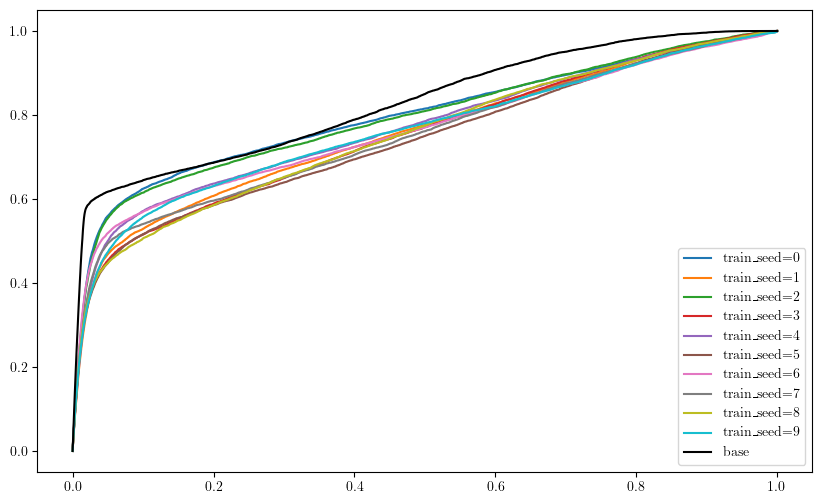

In [47]:
from plots import plot_sr_stats

seed = 31
signal_ratio = 0.02
n_3b = 100_0000
train_seeds = range(10)
noise_scale = 1.0

train_seed = 0


hashes = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                            "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] == seed and x["n_3b"] == n_3b, 
                            "smearing": lambda x: x["noise_scale"] == noise_scale,
                            "train_seed": 0})
assert len(hashes) == 1, f"Expected 1 hash, got {len(hashes)}"
hash = hashes[0]
events_tst = get_events_tst(hash)
smeared_fvt_tinfo = TrainingInfo.load(hash)
base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
base_fvt_model = base_fvt_tinfo.load_trained_model("best")
base_fvt_model.eval()
base_fvt_model: FvTClassifier
base_fvt_scores = base_fvt_model.predict(events_tst.X_torch).numpy()[:, 1]
base_gamma = base_fvt_scores / (1 - base_fvt_scores)


fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for train_seed in train_seeds:
    hashes = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["seed"] == seed and x["n_3b"] == n_3b, 
                                "smearing": lambda x: x["noise_scale"] == noise_scale,
                                "train_seed": train_seed})
    assert len(hashes) == 1, f"Expected 1 hash, got {len(hashes)}"
    hash = hashes[0]
    smeared_fvt_tinfo = TrainingInfo.load(hash)

    if "SR_stats_tst" in smeared_fvt_tinfo.aux_info.keys():
        SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
    else:
        base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
        base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
        base_fvt_model = base_fvt_tinfo.load_trained_model("best")
        base_fvt_model.eval()
        base_fvt_model: FvTClassifier
        base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
        base_fvt_scores = base_fvt_scores.numpy()[:, 1]
        base_q_repr = base_q_repr.numpy()
        base_gamma = base_fvt_scores / (1 - base_fvt_scores)
        smeared_fvt_model = smeared_fvt_tinfo.load_trained_model("best")
        smeared_fvt_model.eval()
        smeared_fvt_model.to(torch.device("cuda"))
        smeared_fvt_model: AttentionClassifier
        fvt_smeared = smeared_fvt_model.predict(base_q_repr).numpy()[:, 1]
        gamma_smeared = fvt_smeared / (1 - fvt_smeared)
        SR_stats_tst = np.log(base_gamma / gamma_smeared)
        smeared_fvt_tinfo.update_aux_info(SR_stats_tst=SR_stats_tst)
        smeared_fvt_tinfo.save()
        
    plot_sr_stats(events_tst, SR_stats_tst, ax, label=f"train_seed={train_seed}")
    
plot_sr_stats(events_tst, base_gamma, ax, label="base", color="black", linestyle="--")
plt.legend()
plt.show()
        
    

In [31]:
hparams = TrainingInfo.get_existing_hparams()
print(np.unique([hparam["experiment_name"] for hparam in hparams]))

hashes, hparams = TrainingInfo.find({"experiment_name": "base_fvt_training_ensemble"}, return_hparams=True)

['CR_fvt_training' 'CR_fvt_training_repr_norm' 'CR_fvt_training_same_data'
 'CR_fvt_training_schedulefree' 'CR_fvt_training_schedulefree_ablation'
 'CR_fvt_training_schedulefree_ablation2' 'CR_fvt_training_v2'
 'base_fvt_training_ensemble' 'base_fvt_with_repr_norm'
 'base_fvt_with_repr_norm_smaller_repr_dim' 'better_base_fvt_training'
 'better_base_fvt_training_small' 'smeared_fvt_training'
 'smeared_fvt_training_ensemble' 'smeared_fvt_training_noise_scale'
 'smeared_fvt_training_repr_norm' 'smeared_fvt_training_small']


In [32]:
print(np.unique([hparam["dataset"]["seed"] for hparam in hparams]))
print(np.unique([hparam["dataset"]["signal_ratio"] for hparam in hparams]))
print(np.unique([hparam["train_seed"] for hparam in hparams]))
print(len(hashes))

[0 1 2 3 4 5 6 7 8 9]
[0.     0.005  0.0075 0.01   0.02  ]
[0 1 2 3 4]
250


100%|██████████| 50/50 [05:09<00:00,  6.19s/it]


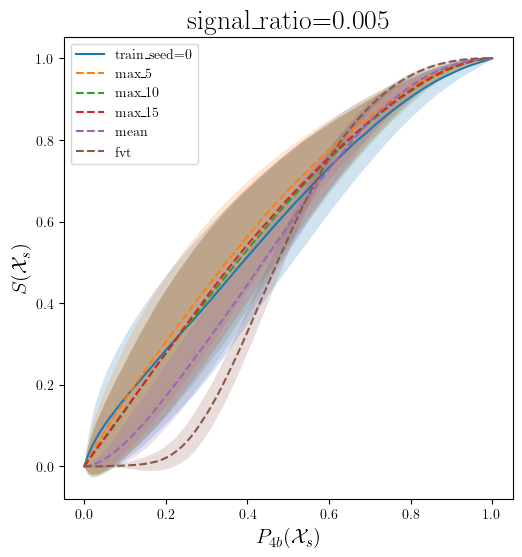

100%|██████████| 50/50 [05:09<00:00,  6.20s/it]


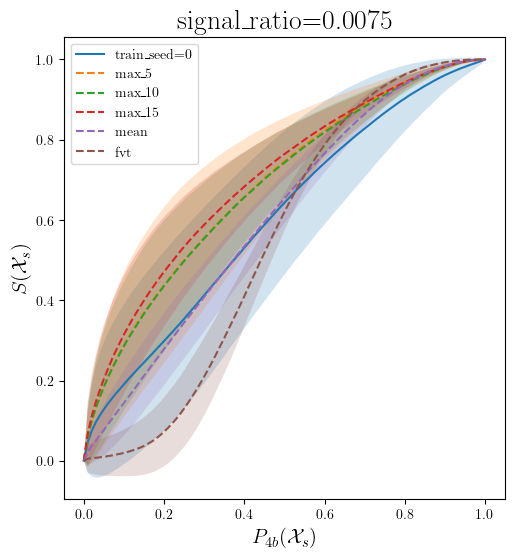

100%|██████████| 50/50 [05:19<00:00,  6.39s/it]


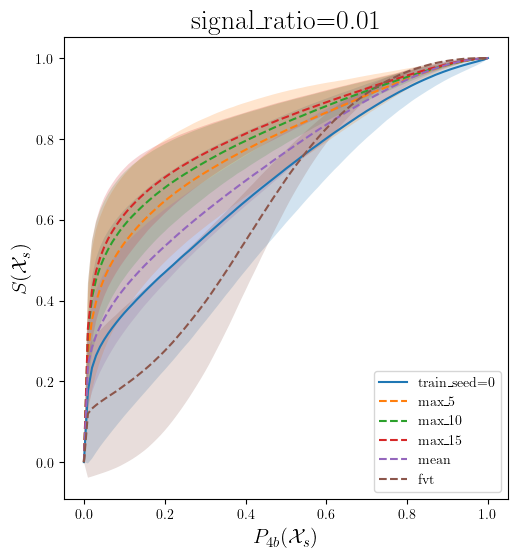

100%|██████████| 50/50 [05:17<00:00,  6.34s/it]


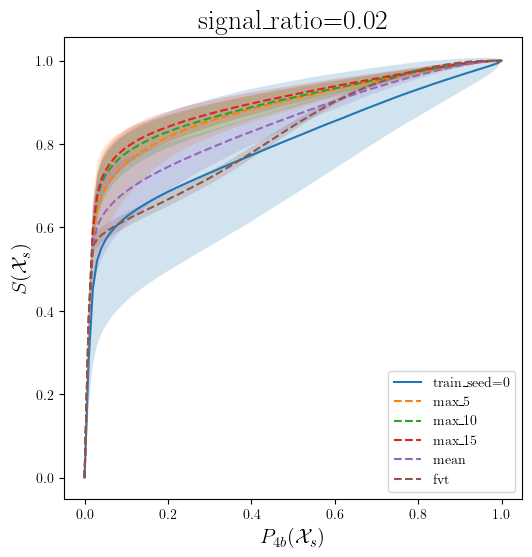

In [9]:
from plots import get_weights_by_sr_stats

n_3b = 100_0000
seeds = range(50)
signal_ratios = [0.005, 0.0075, 0.01, 0.02]
ensemble_seeds = range(15)

for signal_ratio in signal_ratios:
    w_4b_ratio_points = np.arange(0, 1.01, 0.01)
    w_signal_ratio_list = {"max_5": [], "max_10": [], "max_15": [], 
                           "mean": [], 
                           "fvt_mean": [], "fvt_max_5": [], "fvt_max_10": [], "fvt_max_15": []}
    for train_seed in seeds:
        w_signal_ratio_list[train_seed] = []
    
    for seed in tqdm.tqdm(seeds):    
        hashes, hparams = TrainingInfo.find({"experiment_name": "smeared_fvt_training_ensemble", 
                                            "dataset": lambda x: (x["signal_ratio"] == signal_ratio 
                                                                and x["seed"] == seed 
                                                                and x["n_3b"] == n_3b), 
                                            }, return_hparams=True)
        # sort hashes by train_seed
        hashes = sorted(hashes, key=lambda x: hparams[hashes.index(x)]["train_seed"])
        events_tst = get_events_tst(hashes[0])
        SR_stats_list = []
        base_fvt_scores_list = []
        for hash in hashes:
            smeared_fvt_tinfo = TrainingInfo.load(hash)
            train_seed = smeared_fvt_tinfo.hparams["train_seed"]
            SR_stats_tst = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
            SR_stats_list.append(SR_stats_tst)
            w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_tst)
            w_signal_ratio = np.interp(w_4b_ratio_points, w_4b_ratio, w_signal_ratio)
            w_signal_ratio_list[train_seed].append(w_signal_ratio)
            
            base_fvt_tinfo = TrainingInfo.load(smeared_fvt_tinfo.hparams["encoder_hash"])
            base_fvt_model = base_fvt_tinfo.load_trained_model("best")
            base_fvt_model.eval()
            base_fvt_model: FvTClassifier
            base_fvt_scores, _ = base_fvt_model.predict_and_representations(events_tst.X_torch)
            base_fvt_scores = base_fvt_scores.numpy()[:, 1]
            base_fvt_scores_list.append(base_fvt_scores)
            
        base_fvt_scores_mean = np.mean(base_fvt_scores_list, axis=0)
        w_4b_ratio_fvt, w_signal_ratio_fvt = get_weights_by_sr_stats(events_tst, base_fvt_scores_mean)
        w_signal_ratio_fvt = np.interp(w_4b_ratio_points, w_4b_ratio_fvt, w_signal_ratio_fvt)
        w_signal_ratio_list["fvt_mean"].append(w_signal_ratio_fvt)
        
        base_fvt_scores_max_5 = np.max(base_fvt_scores_list[:5], axis=0)
        w_4b_ratio_fvt_max_5, w_signal_ratio_fvt_max_5 = get_weights_by_sr_stats(events_tst, base_fvt_scores_max_5)
        w_signal_ratio_fvt_max_5 = np.interp(w_4b_ratio_points, w_4b_ratio_fvt_max_5, w_signal_ratio_fvt_max_5)
        w_signal_ratio_list["fvt_max_5"].append(w_signal_ratio_fvt_max_5)
        
        base_fvt_scores_max_10 = np.max(base_fvt_scores_list[:10], axis=0)
        w_4b_ratio_fvt_max_10, w_signal_ratio_fvt_max_10 = get_weights_by_sr_stats(events_tst, base_fvt_scores_max_10)
        w_signal_ratio_fvt_max_10 = np.interp(w_4b_ratio_points, w_4b_ratio_fvt_max_10, w_signal_ratio_fvt_max_10)
        w_signal_ratio_list["fvt_max_10"].append(w_signal_ratio_fvt_max_10)
        
        base_fvt_scores_max_15 = np.max(base_fvt_scores_list[:15], axis=0)
        w_4b_ratio_fvt_max_15, w_signal_ratio_fvt_max_15 = get_weights_by_sr_stats(events_tst, base_fvt_scores_max_15)
        w_signal_ratio_fvt_max_15 = np.interp(w_4b_ratio_points, w_4b_ratio_fvt_max_15, w_signal_ratio_fvt_max_15)
        w_signal_ratio_list["fvt_max_15"].append(w_signal_ratio_fvt_max_15)

        SR_stats_max_5 = np.max(SR_stats_list[:5], axis=0)
        w_4b_ratio_max_5, w_signal_ratio_max_5 = get_weights_by_sr_stats(events_tst, SR_stats_max_5)
        w_signal_ratio_max_5 = np.interp(w_4b_ratio_points, w_4b_ratio_max_5, w_signal_ratio_max_5)
        w_signal_ratio_list["max_5"].append(w_signal_ratio_max_5)
        
        SR_stats_max_10 = np.max(SR_stats_list[:10], axis=0)
        w_4b_ratio_max_10, w_signal_ratio_max_10 = get_weights_by_sr_stats(events_tst, SR_stats_max_10)
        w_signal_ratio_max_10 = np.interp(w_4b_ratio_points, w_4b_ratio_max_10, w_signal_ratio_max_10)
        w_signal_ratio_list["max_10"].append(w_signal_ratio_max_10)
        
        SR_stats_max_15 = np.max(SR_stats_list[:15], axis=0)
        w_4b_ratio_max_15, w_signal_ratio_max_15 = get_weights_by_sr_stats(events_tst, SR_stats_max_15)
        w_signal_ratio_max_15 = np.interp(w_4b_ratio_points, w_4b_ratio_max_15, w_signal_ratio_max_15)
        w_signal_ratio_list["max_15"].append(w_signal_ratio_max_15)
        
        SR_stats_mean = np.mean(SR_stats_list, axis=0)
        w_4b_ratio_mean, w_signal_ratio_mean = get_weights_by_sr_stats(events_tst, SR_stats_mean)
        w_signal_ratio_mean = np.interp(w_4b_ratio_points, w_4b_ratio_mean, w_signal_ratio_mean)
        w_signal_ratio_list["mean"].append(w_signal_ratio_mean)

    
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list[0], ax, label="train_seed=0")
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list["max_5"], ax, label="max_5", linestyle="--")
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list["max_10"], ax, label="max_10", linestyle="--")
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list["max_15"], ax, label="max_15", linestyle="--")
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list["mean"], ax, label="mean", linestyle="--")
    plot_mean_and_fill_between_std(w_4b_ratio_points, w_signal_ratio_list["fvt"], ax, label="fvt", linestyle="--")
    
    ax.set_title(f"signal_ratio={signal_ratio}")
    ax.legend()
    ax.set_xlabel(r"$P_{4b}(\mathcal{X}_s)$")
    ax.set_ylabel(r"$S(\mathcal{X}_s)$")
    ax.set_aspect("equal")
    
    plt.savefig(f"data/plots/smeared_gamma_ensemble_avg_signal_ratio={signal_ratio}.pdf")
    plt.show()
    plt.close()